<a href="https://colab.research.google.com/github/ElijahGhaya/ITAI_ML_MIDTERM_TEAM2/blob/main/ML_MID_TERM_Notebook.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split

# 1. Load the raw dataset
df = pd.read_csv('credit_risk_dataset.csv')

# 2. Split the data FIRST (70% training, 30% testing)
# Use 'loan_status' as the target variable to predict
X = df.drop('loan_status', axis=1)
y = df['loan_status']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.30, random_state=42)

# 3. Combine the training features and target back together into one training dataset
train_df = X_train.copy()
train_df['loan_status'] = y_train

# Display the first 5 rows to make sure it worked
train_df.head()

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length,loan_status
12657,25,66300,MORTGAGE,9.0,MEDICAL,A,1700,6.76,0.02,N,4,1
11611,22,75000,MORTGAGE,6.0,MEDICAL,B,25000,9.25,0.33,N,2,0
18223,31,105400,RENT,2.0,MEDICAL,D,24250,15.31,0.20,N,5,1
24772,35,75000,MORTGAGE,5.0,PERSONAL,B,5000,8.70,0.07,N,9,0
30770,36,65000,MORTGAGE,6.0,EDUCATION,C,23325,15.27,0.36,Y,14,0


--- DATASET INFORMATION ---
<class 'pandas.core.frame.DataFrame'>
Index: 22806 entries, 12657 to 23654
Data columns (total 12 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   person_age                  22806 non-null  int64  
 1   person_income               22806 non-null  int64  
 2   person_home_ownership       22806 non-null  object 
 3   person_emp_length           22185 non-null  float64
 4   loan_intent                 22806 non-null  object 
 5   loan_grade                  22806 non-null  object 
 6   loan_amnt                   22806 non-null  int64  
 7   loan_int_rate               20661 non-null  float64
 8   loan_percent_income         22806 non-null  float64
 9   cb_person_default_on_file   22806 non-null  object 
 10  cb_person_cred_hist_length  22806 non-null  int64  
 11  loan_status                 22806 non-null  int64  
dtypes: float64(3), int64(5), object(4)
memory usage: 2.3+ MB


--

,person_age,person_income,person_emp_length,loan_amnt,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,loan_status
count,22806.000000,2.280600e+04,22185.000000,22806.000000,20661.000000,22806.000000,22806.000000,22806.000000
mean,27.756161,6.607929e+04,4.790850,9595.537359,11.002306,0.170294,5.811058,0.216873
std,6.416902,6.490680e+04,4.123617,6310.607816,3.226731,0.106897,4.053376,0.412124
min,20.000000,4.000000e+03,0.000000,500.000000,5.420000,0.000000,2.000000,0.000000
25%,23.000000,3.900000e+04,2.000000,5000.000000,7.900000,0.090000,3.000000,0.000000
50%,26.000000,5.500000e+04,4.000000,8000.000000,10.990000,0.150000,4.000000,0.000000
75%,30.000000,7.950000e+04,7.000000,12250.000000,13.470000,0.230000,8.000000,0.000000
max,144.000000,6.000000e+06,123.000000,35000.000000,22.480000,0.780000,30.000000,1.000000


/tmp/ipykernel_20820/1492287792.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=train_df, x='loan_status', palette='viridis')


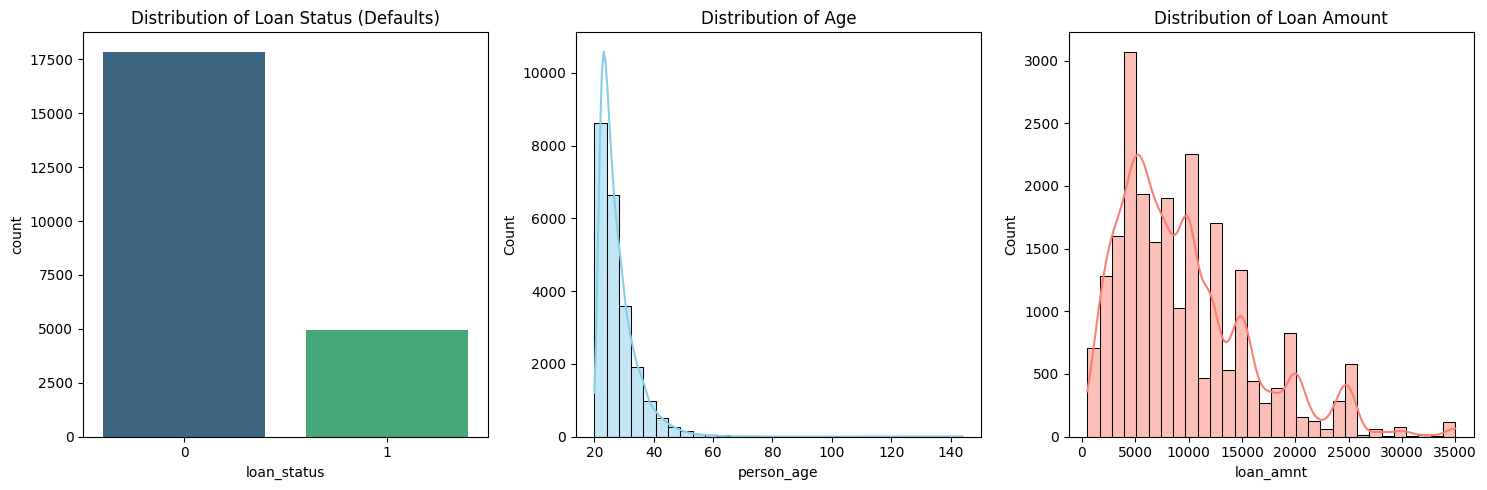

In [2]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Dataset Info (Shows data types and non-null counts)
print("--- DATASET INFORMATION ---")
train_df.info()
print("\n")

# 2. Summary Statistics (Shows mean, min, max, etc. for numerical columns)
print("--- SUMMARY STATISTICS ---")
display(train_df.describe())

# 3. Showing Distributions (Visualizing the data shape)
# Plot the distributions of the target variable and a couple of key features
plt.figure(figsize=(15, 5))

# Plot A: Distribution of Loan Status (Are there more 0s or 1s?)
plt.subplot(1, 3, 1)
sns.countplot(data=train_df, x='loan_status', palette='viridis')
plt.title('Distribution of Loan Status (Defaults)')

# Plot B: Distribution of Age
plt.subplot(1, 3, 2)
sns.histplot(train_df['person_age'], bins=30, kde=True, color='skyblue')
plt.title('Distribution of Age')

# Plot C: Distribution of Loan Amount
plt.subplot(1, 3, 3)
sns.histplot(train_df['loan_amnt'], bins=30, kde=True, color='salmon')
plt.title('Distribution of Loan Amount')

plt.tight_layout()
plt.show()

In [3]:
# 1. Let's see how many missing values we have first
print("Missing values BEFORE cleaning:")
print(train_df.isnull().sum())
print("-" * 30)

# 2. Group-Based Imputation for Interest Rate
# Group by 'loan_grade' and fill blanks with the median interest rate of that specific grade
train_df['loan_int_rate'] = train_df.groupby('loan_grade')['loan_int_rate'].transform(lambda x: x.fillna(x.median()))

# 3. Simple Imputation for Employment Length
# Fill missing employment lengths with the median of the whole column
train_df['person_emp_length'] = train_df['person_emp_length'].fillna(train_df['person_emp_length'].median())

# 4. Check to make sure they are gone
print("Missing values AFTER cleaning:")
print(train_df.isnull().sum())

Missing values BEFORE cleaning:
person_age                       0
person_income                    0
person_home_ownership            0
person_emp_length              621
loan_intent                      0
loan_grade                       0
loan_amnt                        0
loan_int_rate                 2145
loan_percent_income              0
cb_person_default_on_file        0
cb_person_cred_hist_length       0
loan_status                      0
dtype: int64
------------------------------
Missing values AFTER cleaning:
person_age                    0
person_income                 0
person_home_ownership         0
person_emp_length             0
loan_intent                   0
loan_grade                    0
loan_amnt                     0
loan_int_rate                 0
loan_percent_income           0
cb_person_default_on_file     0
cb_person_cred_hist_length    0
loan_status                   0
dtype: int64


In [4]:
# 1. Map Binary Categories (Y/N) to 1/0
train_df['cb_person_default_on_file'] = train_df['cb_person_default_on_file'].map({'Y': 1, 'N': 0})

# 2. Map Ordinal Categories (loan_grade) to numbers
# A is lowest risk (1), G is highest risk (7)
grade_mapping = {'A': 1, 'B': 2, 'C': 3, 'D': 4, 'E': 5, 'F': 6, 'G': 7}
train_df['loan_grade'] = train_df['loan_grade'].map(grade_mapping)

# 3. One-Hot Encoding for Nominal Categories
# This uses pandas 'get_dummies' to create new binary columns for our remaining text
train_df = pd.get_dummies(train_df, columns=['person_home_ownership', 'loan_intent'], drop_first=True)

# Data check
train_df.head()

,person_age,person_income,person_emp_length,loan_grade,loan_amnt,loan_int_rate,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length,loan_status,person_home_ownership_OTHER,person_home_ownership_OWN,person_home_ownership_RENT,loan_intent_EDUCATION,loan_intent_HOMEIMPROVEMENT,loan_intent_MEDICAL,loan_intent_PERSONAL,loan_intent_VENTURE
12657,25,66300,9.0,1,1700,6.76,0.02,0,4,1,False,False,False,False,False,True,False,False
11611,22,75000,6.0,2,25000,9.25,0.33,0,2,0,False,False,False,False,False,True,False,False
18223,31,105400,2.0,4,24250,15.31,0.20,0,5,1,False,False,True,False,False,True,False,False
24772,35,75000,5.0,2,5000,8.70,0.07,0,9,0,False,False,False,False,False,False,True,False
30770,36,65000,6.0,3,23325,15.27,0.36,1,14,0,False,False,False,True,False,False,False,False


In [5]:
from sklearn.preprocessing import MinMaxScaler
import numpy as np

# 1. Feature Engineering: Create a new "Debt-to-Income Ratio" column
train_df['debt_to_income_ratio'] = train_df['loan_amnt'] / train_df['person_income']

# FIX: Find any 'infinity' values caused by dividing by zero, and replace them with 0
train_df.replace([np.inf, -np.inf], 0, inplace=True)

# 2. Convert the True/False columns into 1s and 0s
for col in train_df.select_dtypes(include=['bool']).columns:
    train_df[col] = train_df[col].astype(int)

# 3. Scaling: Apply Min-Max Scaler to our large continuous numbers
scaler = MinMaxScaler()

columns_to_scale = ['person_age', 'person_income', 'person_emp_length',
                    'loan_amnt', 'loan_int_rate', 'cb_person_cred_hist_length',
                    'debt_to_income_ratio']

train_df[columns_to_scale] = scaler.fit_transform(train_df[columns_to_scale])

# Final Data
train_df.head()

,person_age,person_income,person_emp_length,loan_grade,loan_amnt,loan_int_rate,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length,loan_status,person_home_ownership_OTHER,person_home_ownership_OWN,person_home_ownership_RENT,loan_intent_EDUCATION,loan_intent_HOMEIMPROVEMENT,loan_intent_MEDICAL,loan_intent_PERSONAL,loan_intent_VENTURE,debt_to_income_ratio
12657,0.040323,0.010390,0.073171,1,0.034783,0.078546,0.02,0,0.071429,1,0,0,0,0,0,1,0,0,0.032013
11611,0.016129,0.011841,0.048780,2,0.710145,0.224502,0.33,0,0.000000,0,0,0,0,0,0,1,0,0,0.428374
18223,0.088710,0.016911,0.016260,4,0.688406,0.579719,0.20,0,0.107143,1,0,0,1,0,0,1,0,0,0.295360
24772,0.120968,0.011841,0.040650,2,0.130435,0.192263,0.07,0,0.250000,0,0,0,0,0,0,0,1,0,0.084861
30770,0.129032,0.010173,0.048780,3,0.661594,0.577374,0.36,1,0.428571,0,0,0,0,1,0,0,0,0,0.461239


In [6]:
# 1. Fix Missing Values in X_test
X_test['loan_int_rate'] = X_test.groupby('loan_grade')['loan_int_rate'].transform(lambda x: x.fillna(x.median()))
X_test['person_emp_length'] = X_test['person_emp_length'].fillna(train_df['person_emp_length'].median())

# 2. Encode Categories
X_test['cb_person_default_on_file'] = X_test['cb_person_default_on_file'].map({'Y': 1, 'N': 0})
X_test['loan_grade'] = X_test['loan_grade'].map(grade_mapping)
X_test = pd.get_dummies(X_test, columns=['person_home_ownership', 'loan_intent'], drop_first=True)

# 3. Feature Engineering
X_test['debt_to_income_ratio'] = X_test['loan_amnt'] / X_test['person_income']
X_test.replace([np.inf, -np.inf], 0, inplace=True) # Catch those zero-division errors!

for col in X_test.select_dtypes(include=['bool']).columns:
    X_test[col] = X_test[col].astype(int)

# 4. Scale using the ALREADY TRAINED scaler
X_test[columns_to_scale] = scaler.transform(X_test[columns_to_scale])

# 5. Export and Download!
X_test.to_csv('cleaned_credit_risk_testing_data.csv', index=False)
from google.colab import files
files.download('cleaned_credit_risk_testing_data.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>